In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Dosya yolları
red_path = r"C:\veri\S2A_MSIL2A_20260912T084731_N0512_R107_T35TPF_20260912T141609.SAFE\GRANULE\L2A_T35TPF_A058620_20260912T085604\IMG_DATA\R10m\T35TPF_20260912T084731_B04_10m.jp2"
nir_path = r"C:\veri\S2A_MSIL2A_20260912T084731_N0512_R107_T35TPF_20260912T141609.SAFE\GRANULE\L2A_T35TPF_A058620_20260912T085604\IMG_DATA\R10m\T35TPF_20260912T084731_B08_10m.jp2"

# Bantları oku
with rasterio.open(red_path) as src:
    red = src.read(1).astype('float32')

with rasterio.open(nir_path) as src:
    nir = src.read(1).astype('float32')

print("Kırmızı bant boyutu:", red.shape)
print("NIR bant boyutu:", nir.shape)

Kırmızı bant boyutu: (10980, 10980)
NIR bant boyutu: (10980, 10980)


In [2]:
# NDVI hesapla: (NIR - Red) / (NIR + Red)
# 0'a bölme hatasını önlemek için küçük bir değer ekliyoruz
ndvi = (nir - red) / (nir + red + 1e-10)

print("NDVI minimum değer:", ndvi.min())
print("NDVI maksimum değer:", ndvi.max())

NDVI minimum değer: -1.0
NDVI maksimum değer: 1.0


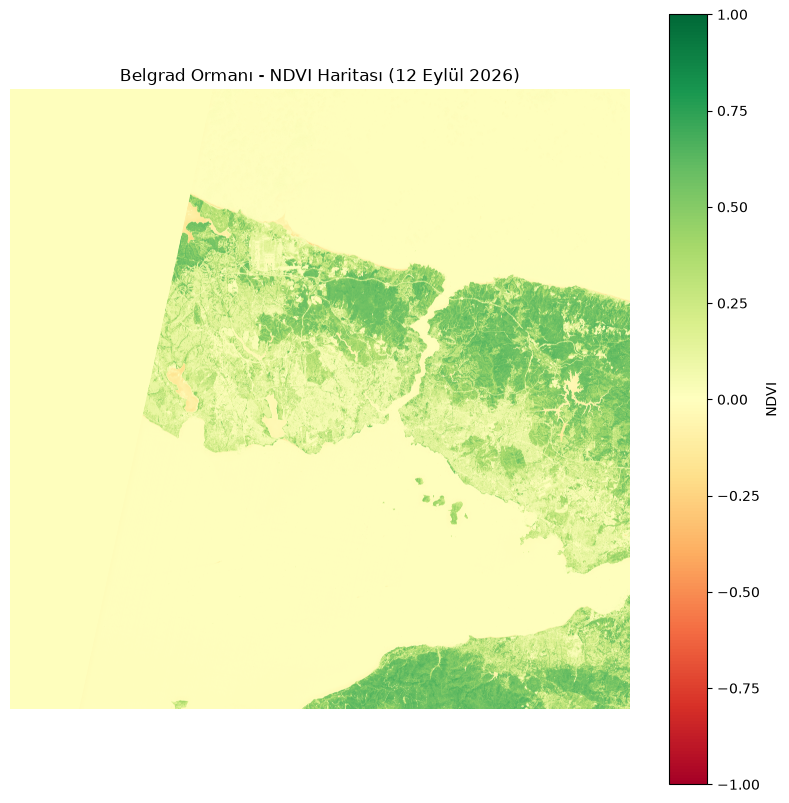

In [3]:
plt.figure(figsize=(10, 10))
plt.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='NDVI')
plt.title('Belgrad Ormanı - NDVI Haritası (12 Eylül 2026)')
plt.axis('off')
plt.show()